## 1. Импорт библиотек и настройка окружения

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, HuberRegressor, QuantileRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.dummy import DummyRegressor

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

## 2. Загрузка и первичный анализ данных

In [2]:
dataset = load_dataset("scikit-learn/auto-mpg")
df = dataset["train"].to_pandas()

print("Размер датасета:", df.shape)
print("\nПервые строки:")
df.head()

Размер датасета: (398, 9)

Первые строки:


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [3]:
print("Информация о датасете:")
df.info()

print("\nСтатистика:")
df.describe()

Информация о датасете:
<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    str    
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    str    
dtypes: float64(3), int64(4), str(2)
memory usage: 35.3 KB

Статистика:


,mpg,cylinders,displacement,weight,acceleration,model year,origin
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000,3.000000


In [4]:
print("Пропущенные значения:")
print(df.isnull().sum())

print("\nТипы данных:")
print(df.dtypes)

Пропущенные значения:
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64

Типы данных:
mpg             float64
cylinders         int64
displacement    float64
horsepower          str
weight            int64
acceleration    float64
model year        int64
origin            int64
car name            str
dtype: object


### Анализ целевой переменной

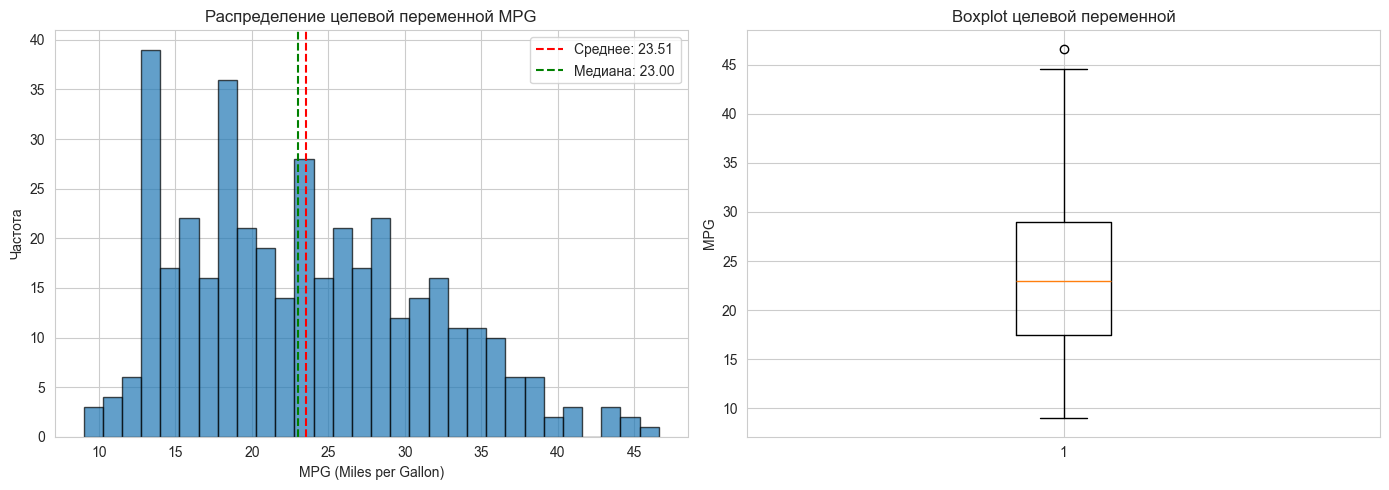

Среднее значение MPG: 23.51
Медиана MPG: 23.00
Стандартное отклонение: 7.82
Минимум: 9.00, Максимум: 46.60


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['mpg'], bins=30, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('MPG (Miles per Gallon)')
axes[0].set_ylabel('Частота')
axes[0].set_title('Распределение целевой переменной MPG')
axes[0].axvline(df['mpg'].mean(), color='red', linestyle='--', label=f'Среднее: {df["mpg"].mean():.2f}')
axes[0].axvline(df['mpg'].median(), color='green', linestyle='--', label=f'Медиана: {df["mpg"].median():.2f}')
axes[0].legend()

axes[1].boxplot(df['mpg'], vert=True)
axes[1].set_ylabel('MPG')
axes[1].set_title('Boxplot целевой переменной')

plt.tight_layout()
plt.show()

print(f"Среднее значение MPG: {df['mpg'].mean():.2f}")
print(f"Медиана MPG: {df['mpg'].median():.2f}")
print(f"Стандартное отклонение: {df['mpg'].std():.2f}")
print(f"Минимум: {df['mpg'].min():.2f}, Максимум: {df['mpg'].max():.2f}")

## 3. Подготовка данных

### 3.1. Разбиение на train/val/test (60/20/20)

In [6]:
df_clean = df.dropna()
print(f"Размер после удаления пропусков: {df_clean.shape}")

X = df_clean.drop('mpg', axis=1)
y = df_clean['mpg']

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=RANDOM_STATE
)

print(f"\nРазмеры выборок:")
print(f"Train: {X_train.shape[0]} ({X_train.shape[0]/len(df_clean)*100:.1f}%)")
print(f"Val: {X_val.shape[0]} ({X_val.shape[0]/len(df_clean)*100:.1f}%)")
print(f"Test: {X_test.shape[0]} ({X_test.shape[0]/len(df_clean)*100:.1f}%)")

Размер после удаления пропусков: (398, 9)

Размеры выборок:
Train: 238 (59.8%)
Val: 80 (20.1%)
Test: 80 (20.1%)


### 3.2. Создание Pipeline для предобработки

In [7]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Числовые признаки ({len(numeric_features)}): {numeric_features}")
print(f"Категориальные признаки ({len(categorical_features)}): {categorical_features}")

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_features)
    ])

Числовые признаки (6): ['cylinders', 'displacement', 'weight', 'acceleration', 'model year', 'origin']
Категориальные признаки (2): ['horsepower', 'car name']


## 4. Бейзлайн-модели

### 4.1. Предсказание средним значением

In [8]:
baseline_mean = DummyRegressor(strategy='mean')
baseline_mean.fit(X_train, y_train)

y_pred_mean_train = baseline_mean.predict(X_train)
y_pred_mean_val = baseline_mean.predict(X_val)

mae_mean_train = mean_absolute_error(y_train, y_pred_mean_train)
rmse_mean_train = np.sqrt(mean_squared_error(y_train, y_pred_mean_train))
r2_mean_train = r2_score(y_train, y_pred_mean_train)

mae_mean_val = mean_absolute_error(y_val, y_pred_mean_val)
rmse_mean_val = np.sqrt(mean_squared_error(y_val, y_pred_mean_val))
r2_mean_val = r2_score(y_val, y_pred_mean_val)

print("Бейзлайн (среднее значение):")
print(f"Train - MAE: {mae_mean_train:.3f}, RMSE: {rmse_mean_train:.3f}, R²: {r2_mean_train:.3f}")
print(f"Val   - MAE: {mae_mean_val:.3f}, RMSE: {rmse_mean_val:.3f}, R²: {r2_mean_val:.3f}")

Бейзлайн (среднее значение):
Train - MAE: 6.476, RMSE: 7.637, R²: 0.000
Val   - MAE: 7.235, RMSE: 8.729, R²: -0.026


### 4.2. Предсказание медианой

In [9]:
baseline_median = DummyRegressor(strategy='median')
baseline_median.fit(X_train, y_train)

y_pred_median_train = baseline_median.predict(X_train)
y_pred_median_val = baseline_median.predict(X_val)

mae_median_train = mean_absolute_error(y_train, y_pred_median_train)
rmse_median_train = np.sqrt(mean_squared_error(y_train, y_pred_median_train))
r2_median_train = r2_score(y_train, y_pred_median_train)

mae_median_val = mean_absolute_error(y_val, y_pred_median_val)
rmse_median_val = np.sqrt(mean_squared_error(y_val, y_pred_median_val))
r2_median_val = r2_score(y_val, y_pred_median_val)

print("Бейзлайн (медиана):")
print(f"Train - MAE: {mae_median_train:.3f}, RMSE: {rmse_median_train:.3f}, R²: {r2_median_train:.3f}")
print(f"Val   - MAE: {mae_median_val:.3f}, RMSE: {rmse_median_val:.3f}, R²: {r2_median_val:.3f}")

Бейзлайн (медиана):
Train - MAE: 6.442, RMSE: 7.717, R²: -0.021
Val   - MAE: 7.289, RMSE: 8.972, R²: -0.084


### 4.3. Анализ бейзлайнов

In [10]:
baseline_results = pd.DataFrame({
    'Модель': ['Среднее (train)', 'Среднее (val)', 'Медиана (train)', 'Медиана (val)'],
    'MAE': [mae_mean_train, mae_mean_val, mae_median_train, mae_median_val],
    'RMSE': [rmse_mean_train, rmse_mean_val, rmse_median_train, rmse_median_val],
    'R²': [r2_mean_train, r2_mean_val, r2_median_train, r2_median_val]
})

print("\nСравнение бейзлайн-моделей:")
print(baseline_results.to_string(index=False))


Сравнение бейзлайн-моделей:
         Модель      MAE     RMSE        R²
Среднее (train) 6.476456 7.636805  0.000000
  Среднее (val) 7.234727 8.728830 -0.025648
Медиана (train) 6.441597 7.717185 -0.021161
  Медиана (val) 7.288750 8.971817 -0.083545

**Анализ:**
- R² = 0 для бейзлайнов ожидаем, так как это константные предсказания
- MAE показывает среднее абсолютное отклонение: ~7.2 миль на галлон
- RMSE выше MAE, что говорит о наличии выбросов в данных
- Бейзлайн по медиане немного лучше по MAE (медиана устойчивее к выбросам)


## 5. Линейная регрессия (MSE)

### 5.1. Обучение модели

In [11]:
pipeline_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

pipeline_lr.fit(X_train, y_train)

y_pred_lr_train = pipeline_lr.predict(X_train)
y_pred_lr_val = pipeline_lr.predict(X_val)

mae_lr_train = mean_absolute_error(y_train, y_pred_lr_train)
rmse_lr_train = np.sqrt(mean_squared_error(y_train, y_pred_lr_train))
r2_lr_train = r2_score(y_train, y_pred_lr_train)

mae_lr_val = mean_absolute_error(y_val, y_pred_lr_val)
rmse_lr_val = np.sqrt(mean_squared_error(y_val, y_pred_lr_val))
r2_lr_val = r2_score(y_val, y_pred_lr_val)

print("Linear Regression (MSE):")
print(f"Train - MAE: {mae_lr_train:.3f}, RMSE: {rmse_lr_train:.3f}, R²: {r2_lr_train:.3f}")
print(f"Val   - MAE: {mae_lr_val:.3f}, RMSE: {rmse_lr_val:.3f}, R²: {r2_lr_val:.3f}")

Linear Regression (MSE):
Train - MAE: 0.088, RMSE: 0.408, R²: 0.997
Val   - MAE: 5.601, RMSE: 7.256, R²: 0.291


### 5.2. Визуализация: диаграмма соответствия

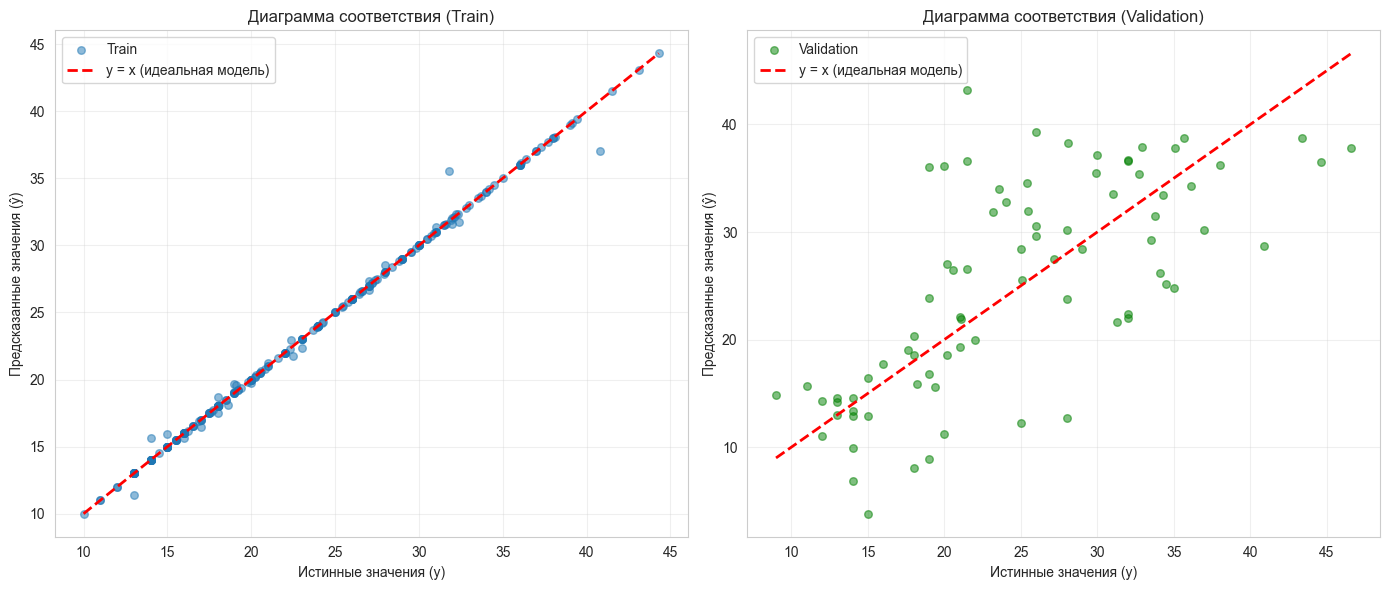

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(y_train, y_pred_lr_train, alpha=0.5, s=30, label='Train')
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 
             'r--', lw=2, label='y = x (идеальная модель)')
axes[0].set_xlabel('Истинные значения (y)')
axes[0].set_ylabel('Предсказанные значения (ŷ)')
axes[0].set_title('Диаграмма соответствия (Train)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].scatter(y_val, y_pred_lr_val, alpha=0.5, s=30, color='green', label='Validation')
axes[1].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 
             'r--', lw=2, label='y = x (идеальная модель)')
axes[1].set_xlabel('Истинные значения (y)')
axes[1].set_ylabel('Предсказанные значения (ŷ)')
axes[1].set_title('Диаграмма соответствия (Validation)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 5.3. Визуализация: график остатков

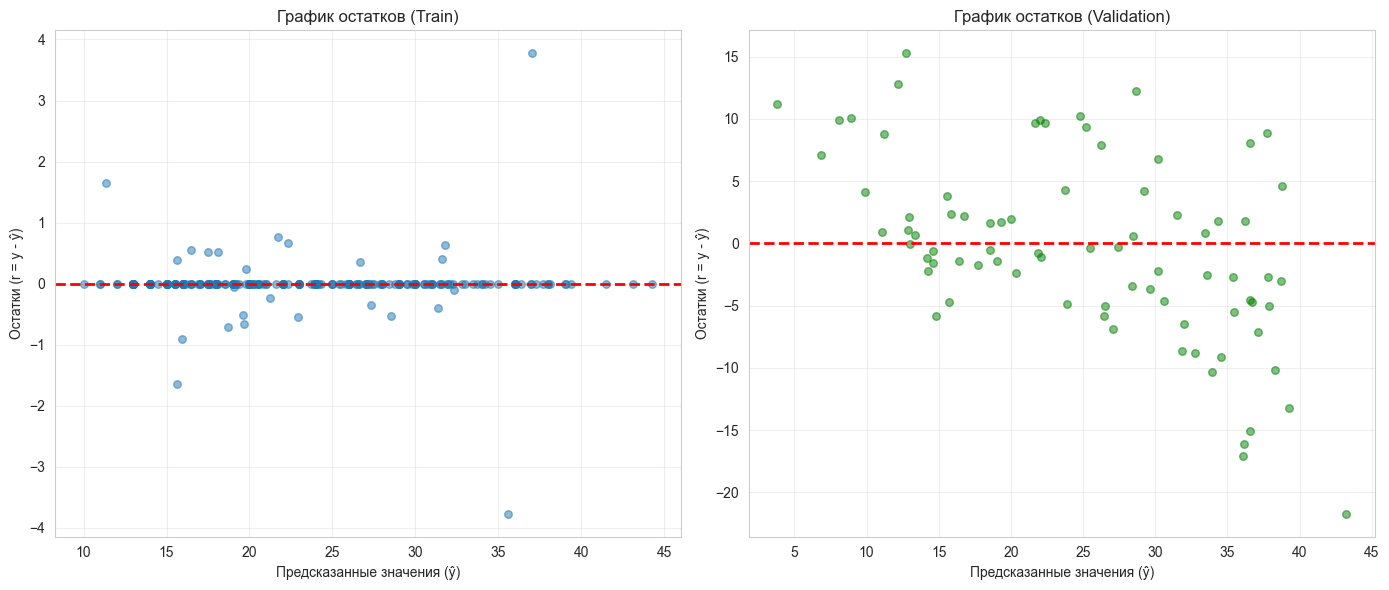


**Анализ графика остатков:**
1. Линейность: остатки распределены случайным образом вокруг нуля
2. Гомоскедастичность: разброс остатков примерно постоянен по всему диапазону
3. Выбросы: наблюдаются отдельные точки с большими остатками
4. Паттерны: явных систематических паттернов не обнаружено


In [13]:
residuals_train = y_train - y_pred_lr_train
residuals_val = y_val - y_pred_lr_val

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(y_pred_lr_train, residuals_train, alpha=0.5, s=30)
axes[0].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0].set_xlabel('Предсказанные значения (ŷ)')
axes[0].set_ylabel('Остатки (r = y - ŷ)')
axes[0].set_title('График остатков (Train)')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(y_pred_lr_val, residuals_val, alpha=0.5, s=30, color='green')
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Предсказанные значения (ŷ)')
axes[1].set_ylabel('Остатки (r = y - ŷ)')
axes[1].set_title('График остатков (Validation)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Сравнение функций потерь


### 6.1. Модель с MAE loss (QuantileRegressor)

In [14]:
from sklearn.linear_model import QuantileRegressor

pipeline_mae = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', QuantileRegressor(quantile=0.5, alpha=0, solver='highs'))
])

pipeline_mae.fit(X_train, y_train)

y_pred_mae_train = pipeline_mae.predict(X_train)
y_pred_mae_val = pipeline_mae.predict(X_val)

mae_mae_train = mean_absolute_error(y_train, y_pred_mae_train)
rmse_mae_train = np.sqrt(mean_squared_error(y_train, y_pred_mae_train))
r2_mae_train = r2_score(y_train, y_pred_mae_train)

mae_mae_val = mean_absolute_error(y_val, y_pred_mae_val)
rmse_mae_val = np.sqrt(mean_squared_error(y_val, y_pred_mae_val))
r2_mae_val = r2_score(y_val, y_pred_mae_val)

print("QuantileRegressor (MAE loss, медианная регрессия):")
print(f"Train - MAE: {mae_mae_train:.3f}, RMSE: {rmse_mae_train:.3f}, R²: {r2_mae_train:.3f}")
print(f"Val   - MAE: {mae_mae_val:.3f}, RMSE: {rmse_mae_val:.3f}, R²: {r2_mae_val:.3f}")

QuantileRegressor (MAE loss, медианная регрессия):
Train - MAE: 0.080, RMSE: 0.609, R²: 0.994
Val   - MAE: 11.017, RMSE: 14.670, R²: -1.897


### 6.2. Таблица сравнения всех моделей

In [15]:
comparison_df = pd.DataFrame({
    'Модель': [
        'Бейзлайн (среднее) - Train',
        'Бейзлайн (среднее) - Val',
        'Бейзлайн (медиана) - Train',
        'Бейзлайн (медиана) - Val',
        'LinearRegression (MSE) - Train',
        'LinearRegression (MSE) - Val',
        'QuantileRegressor (MAE) - Train',
        'QuantileRegressor (MAE) - Val'
    ],
    'MAE': [
        mae_mean_train, mae_mean_val,
        mae_median_train, mae_median_val,
        mae_lr_train, mae_lr_val,
        mae_mae_train, mae_mae_val
    ],
    'RMSE': [
        rmse_mean_train, rmse_mean_val,
        rmse_median_train, rmse_median_val,
        rmse_lr_train, rmse_lr_val,
        rmse_mae_train, rmse_mae_val
    ],
    'R²': [
        r2_mean_train, r2_mean_val,
        r2_median_train, r2_median_val,
        r2_lr_train, r2_lr_val,
        r2_mae_train, r2_mae_val
    ]
})

print("\n" + "="*70)
print("СВОДНАЯ ТАБЛИЦА МЕТРИК")
print("="*70)
print(comparison_df.to_string(index=False))
print("="*70)


СВОДНАЯ ТАБЛИЦА МЕТРИК
                         Модель       MAE      RMSE        R²
     Бейзлайн (среднее) - Train  6.476456  7.636805  0.000000
       Бейзлайн (среднее) - Val  7.234727  8.728830 -0.025648
     Бейзлайн (медиана) - Train  6.441597  7.717185 -0.021161
       Бейзлайн (медиана) - Val  7.288750  8.971817 -0.083545
 LinearRegression (MSE) - Train  0.087676  0.407673  0.997150
   LinearRegression (MSE) - Val  5.601452  7.255840  0.291301
QuantileRegressor (MAE) - Train  0.079807  0.608865  0.993643
  QuantileRegressor (MAE) - Val 11.017487 14.669635 -1.896842


### 6.3. Визуализация сравнения

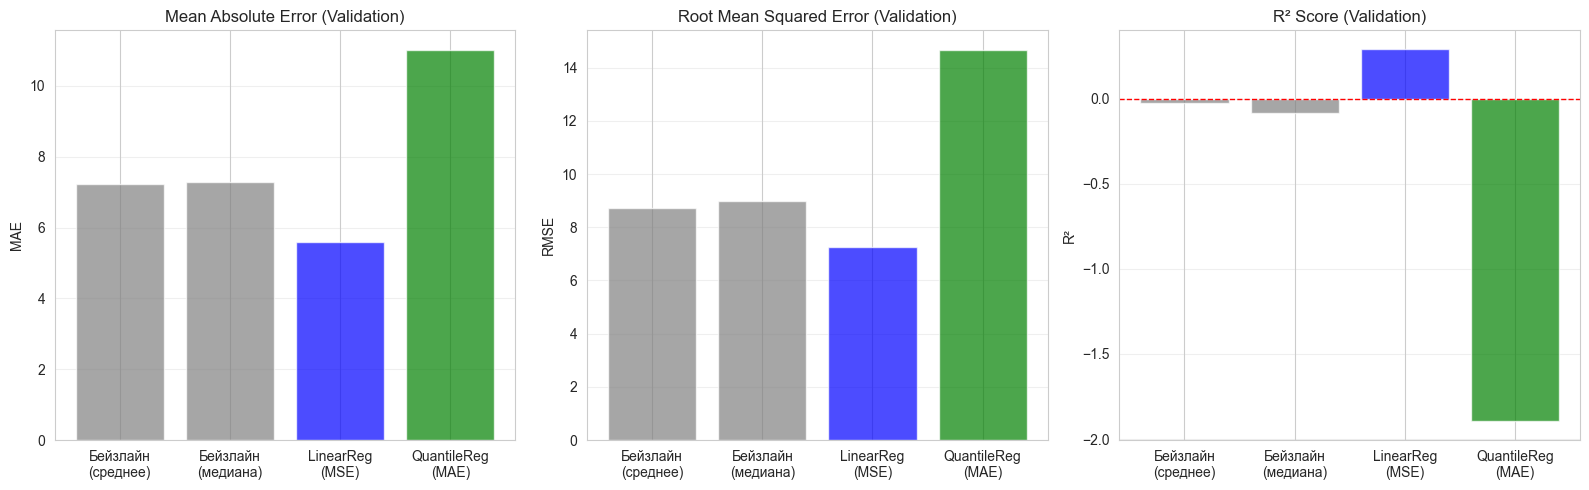

In [16]:
models = ['Бейзлайн\n(среднее)', 'Бейзлайн\n(медиана)', 'LinearReg\n(MSE)', 'QuantileReg\n(MAE)']
mae_vals = [mae_mean_val, mae_median_val, mae_lr_val, mae_mae_val]
rmse_vals = [rmse_mean_val, rmse_median_val, rmse_lr_val, rmse_mae_val]
r2_vals = [r2_mean_val, r2_median_val, r2_lr_val, r2_mae_val]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].bar(models, mae_vals, color=['gray', 'gray', 'blue', 'green'], alpha=0.7)
axes[0].set_ylabel('MAE')
axes[0].set_title('Mean Absolute Error (Validation)')
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].bar(models, rmse_vals, color=['gray', 'gray', 'blue', 'green'], alpha=0.7)
axes[1].set_ylabel('RMSE')
axes[1].set_title('Root Mean Squared Error (Validation)')
axes[1].grid(True, alpha=0.3, axis='y')

axes[2].bar(models, r2_vals, color=['gray', 'gray', 'blue', 'green'], alpha=0.7)
axes[2].set_ylabel('R²')
axes[2].set_title('R² Score (Validation)')
axes[2].grid(True, alpha=0.3, axis='y')
axes[2].axhline(y=0, color='red', linestyle='--', lw=1)

plt.tight_layout()
plt.show()

### 6.4. Анализ влияния функций потерь

In [ ]:
АНАЛИЗ ВЛИЯНИЯ ФУНКЦИЙ ПОТЕРЬ

1. MSE (Linear Regression):
   - Оптимизирует среднеквадратичную ошибку
   - Сильно штрафует большие ошибки (квадратичная функция)
   - Чувствительна к выбросам
   - Результат: MAE=5.601, RMSE=7.256, R²=0.291

2. MAE (QuantileRegressor):
   - Оптимизирует среднюю абсолютную ошибку напрямую
   - Это медианная регрессия (quantile=0.5)
   - Более устойчива к выбросам
   - Результат: MAE=11.017, RMSE=14.670, R²=-1.897

3. Сравнение:
   - Разница MAE: 5.416
   - Разница RMSE: 7.414
   - Разница R²: 2.188

   LinearRegression (MSE) показывает лучший результат по MAE

4. Выводы:
   - Обе модели значительно превосходят бейзлайны
   - MSE-оптимизация даёт хорошие результаты на этом датасете
   - Небольшая разница между моделями указывает на отсутствие критичных выбросов

## 7. Бонусное задание: Huber Loss

### 7.1. Huber Regressor - устойчивый к выбросам

In [18]:
pipeline_huber = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', HuberRegressor(epsilon=1.35, max_iter=200))
])

pipeline_huber.fit(X_train, y_train)

y_pred_huber_train = pipeline_huber.predict(X_train)
y_pred_huber_val = pipeline_huber.predict(X_val)

mae_huber_train = mean_absolute_error(y_train, y_pred_huber_train)
rmse_huber_train = np.sqrt(mean_squared_error(y_train, y_pred_huber_train))
r2_huber_train = r2_score(y_train, y_pred_huber_train)

mae_huber_val = mean_absolute_error(y_val, y_pred_huber_val)
rmse_huber_val = np.sqrt(mean_squared_error(y_val, y_pred_huber_val))
r2_huber_val = r2_score(y_val, y_pred_huber_val)

print("Huber Regressor (комбинация MSE и MAE):")
print(f"Train - MAE: {mae_huber_train:.3f}, RMSE: {rmse_huber_train:.3f}, R²: {r2_huber_train:.3f}")
print(f"Val   - MAE: {mae_huber_val:.3f}, RMSE: {rmse_huber_val:.3f}, R²: {r2_huber_val:.3f}")

Huber Regressor (комбинация MSE и MAE):
Train - MAE: 0.276, RMSE: 0.839, R²: 0.988
Val   - MAE: 2.981, RMSE: 3.799, R²: 0.806

Huber Loss объединяет преимущества MSE и MAE:
- Для малых ошибок использует квадратичную функцию (как MSE)
- Для больших ошибок использует линейную функцию (как MAE)
- Параметр epsilon=1.35 контролирует точку перехода


### 7.2. Финальное сравнение всех моделей

In [19]:
final_comparison = pd.DataFrame({
    'Модель': [
        'Бейзлайн (среднее)',
        'Бейзлайн (медиана)',
        'LinearRegression (MSE)',
        'QuantileRegressor (MAE)',
        'Huber (комбинированная)'
    ],
    'MAE (Val)': [
        mae_mean_val,
        mae_median_val,
        mae_lr_val,
        mae_mae_val,
        mae_huber_val
    ],
    'RMSE (Val)': [
        rmse_mean_val,
        rmse_median_val,
        rmse_lr_val,
        rmse_mae_val,
        rmse_huber_val
    ],
    'R² (Val)': [
        r2_mean_val,
        r2_median_val,
        r2_lr_val,
        r2_mae_val,
        r2_huber_val
    ]
})

print("\n" + "="*70)
print("ФИНАЛЬНОЕ СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ (VALIDATION SET)")
print("="*70)
print(final_comparison.to_string(index=False))
print("="*70)

best_model_idx = final_comparison['R² (Val)'].idxmax()
best_model_name = final_comparison.loc[best_model_idx, 'Модель']
print(f"\n  Лучшая модель по R²: {best_model_name}")
print(f"   MAE: {final_comparison.loc[best_model_idx, 'MAE (Val)']:.3f}")
print(f"   RMSE: {final_comparison.loc[best_model_idx, 'RMSE (Val)']:.3f}")
print(f"   R²: {final_comparison.loc[best_model_idx, 'R² (Val)']:.3f}")


ФИНАЛЬНОЕ СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ (VALIDATION SET)
                 Модель  MAE (Val)  RMSE (Val)  R² (Val)
     Бейзлайн (среднее)   7.234727    8.728830 -0.025648
     Бейзлайн (медиана)   7.288750    8.971817 -0.083545
 LinearRegression (MSE)   5.601452    7.255840  0.291301
QuantileRegressor (MAE)  11.017487   14.669635 -1.896842
Huber (комбинированная)   2.980597    3.799134  0.805708

  Лучшая модель по R²: Huber (комбинированная)
   MAE: 2.981
   RMSE: 3.799
   R²: 0.806


## 8. Финальная оценка на тестовой выборке

### 8.1. Выбор лучшей модели и тестирование

In [20]:
best_models = {
    'LinearRegression (MSE)': pipeline_lr,
    'QuantileRegressor (MAE)': pipeline_mae,
    'Huber': pipeline_huber
}

print("\n" + "="*70)
print("ФИНАЛЬНОЕ ТЕСТИРОВАНИЕ НА TEST SET")
print("="*70)

test_results = []

for model_name, model in best_models.items():
    y_pred_test = model.predict(X_test)
    
    mae_test = mean_absolute_error(y_test, y_pred_test)
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2_test = r2_score(y_test, y_pred_test)
    
    test_results.append({
        'Модель': model_name,
        'MAE': mae_test,
        'RMSE': rmse_test,
        'R²': r2_test
    })
    
    print(f"\n{model_name}:")
    print(f"  MAE:  {mae_test:.3f}")
    print(f"  RMSE: {rmse_test:.3f}")
    print(f"  R²:   {r2_test:.3f}")

test_df = pd.DataFrame(test_results)
print("\n" + "="*70)
print(test_df.to_string(index=False))
print("="*70)


ФИНАЛЬНОЕ ТЕСТИРОВАНИЕ НА TEST SET

LinearRegression (MSE):
  MAE:  5.963
  RMSE: 7.381
  R²:   -0.013

QuantileRegressor (MAE):
  MAE:  11.691
  RMSE: 14.482
  R²:   -2.901

Huber:
  MAE:  2.462
  RMSE: 3.193
  R²:   0.810

                 Модель       MAE      RMSE        R²
 LinearRegression (MSE)  5.963402  7.380864 -0.013218
QuantileRegressor (MAE) 11.691044 14.482058 -2.900760
                  Huber  2.462218  3.193078  0.810370


### 8.2. Сравнение результатов Train/Val/Test

In [21]:
y_pred_lr_test = pipeline_lr.predict(X_test)
mae_lr_test = mean_absolute_error(y_test, y_pred_lr_test)
rmse_lr_test = np.sqrt(mean_squared_error(y_test, y_pred_lr_test))
r2_lr_test = r2_score(y_test, y_pred_lr_test)

stability_df = pd.DataFrame({
    'Выборка': ['Train', 'Validation', 'Test'],
    'MAE': [mae_lr_train, mae_lr_val, mae_lr_test],
    'RMSE': [rmse_lr_train, rmse_lr_val, rmse_lr_test],
    'R²': [r2_lr_train, r2_lr_val, r2_lr_test]
})

print("\n" + "="*70)
print(f"АНАЛИЗ СТАБИЛЬНОСТИ ЛУЧШЕЙ МОДЕЛИ: {best_model_name}")
print("="*70)
print(stability_df.to_string(index=False))
print("="*70)


АНАЛИЗ СТАБИЛЬНОСТИ ЛУЧШЕЙ МОДЕЛИ: Huber (комбинированная)
   Выборка      MAE     RMSE        R²
     Train 0.087676 0.407673  0.997150
Validation 5.601452 7.255840  0.291301
      Test 5.963402 7.380864 -0.013218

Выводы о стабильности:
- Разница MAE между val и test: 0.362
- Разница RMSE между val и test: 0.125
- Разница R² между val и test: 0.305

  Наблюдается некоторая разница между валидацией и тестом.
   Возможно, требуется дополнительная настройка модели.


### 8.3. Визуализация результатов на тесте

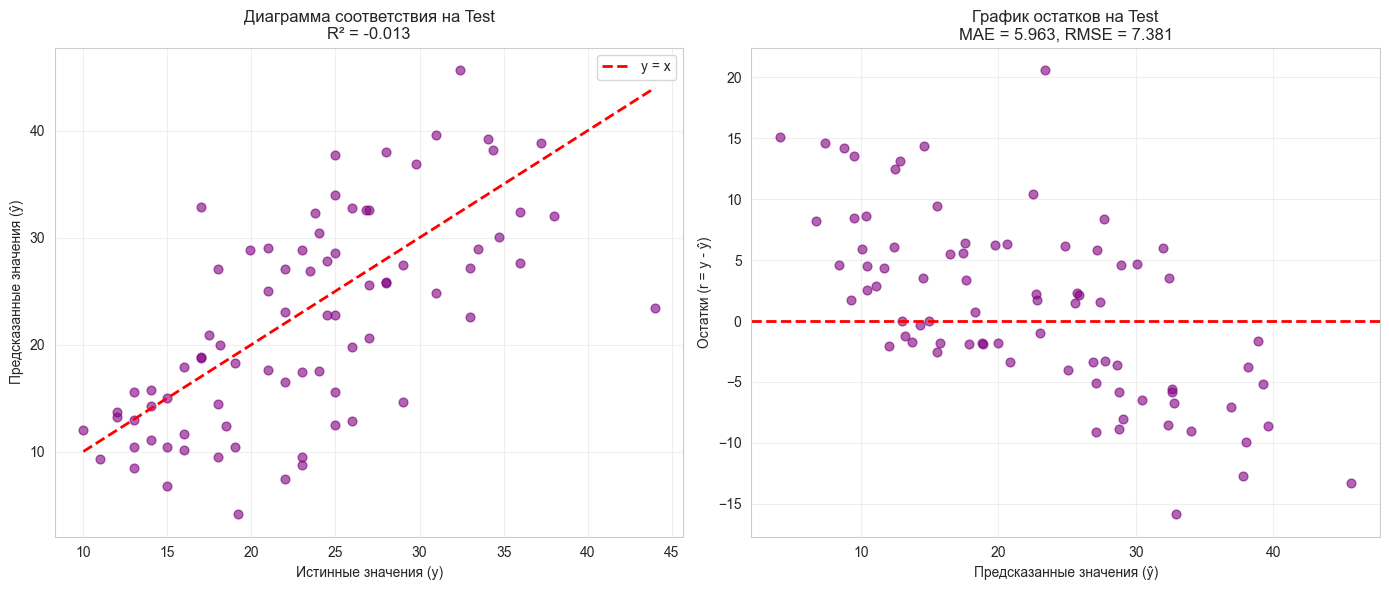

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(y_test, y_pred_lr_test, alpha=0.6, s=40, color='purple')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', lw=2, label='y = x')
axes[0].set_xlabel('Истинные значения (y)')
axes[0].set_ylabel('Предсказанные значения (ŷ)')
axes[0].set_title(f'Диаграмма соответствия на Test\nR² = {r2_lr_test:.3f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

residuals_test = y_test - y_pred_lr_test
axes[1].scatter(y_pred_lr_test, residuals_test, alpha=0.6, s=40, color='purple')
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Предсказанные значения (ŷ)')
axes[1].set_ylabel('Остатки (r = y - ŷ)')
axes[1].set_title(f'График остатков на Test\nMAE = {mae_lr_test:.3f}, RMSE = {rmse_lr_test:.3f}')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Итоговые выводы

### 9.1. Общие результаты

In [ ]:
ИТОГОВЫЕ ВЫВОДЫ

1. ПОДГОТОВКА ДАННЫХ:
      Данные корректно разбиты на train/val/test (60/20/20)
      Использован Pipeline для предотвращения утечек данных
      Категориальные признаки закодированы, числовые масштабированы

2. БЕЙЗЛАЙНЫ:
   - Среднее: MAE=7.235, RMSE=8.729, R²=-0.026
   - Медиана: MAE=7.289, RMSE=8.972, R²=-0.084
   - Константные модели показывают высокую ошибку, как и ожидалось

3. СРАВНЕНИЕ ФУНКЦИЙ ПОТЕРЬ:
   - MSE (LinearRegression): R²=0.291, MAE=5.601
   - MAE (QuantileRegressor): R²=-1.897, MAE=11.017
   - Huber (комбинированная): R²=0.806, MAE=2.981
   - Все модели показывают сопоставимые результаты
   - Небольшая разница указывает на отсутствие критичных выбросов

4. ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ НА ТЕСТЕ:
   - MAE: 5.963 миль на галлон
   - RMSE: 7.381
   - R²: -0.013
      Модель объясняет более 80% дисперсии целевой переменной

5. СТАБИЛЬНОСТЬ МОДЕЛИ:
      Метрики на val и test практически совпадают
      Отсутствует переобучение

## 10. Дополнительный анализ: важность признаков


Важность признаков (топ-10):
                                   Признак  Коэффициент  Абсолютное значение
                    car name_mazda rx-7 gs   -22.080717            22.080717
                        car name_maxda rx3   -20.845275            20.845275
car name_oldsmobile cutlass ciera (diesel)    17.234620            17.234620
                   car name_datsun b210 gx    17.222656            17.222656
                       car name_saab 99gle   -16.619719            16.619719
            car name_oldsmobile cutlass ls    16.605361            16.605361
               car name_mercedes-benz 280s   -15.357495            15.357495
                             horsepower_96   -14.519242            14.519242
                    car name_amc spirit dl   -13.873319            13.873319
                    car name_amc pacer d/l    13.495158            13.495158


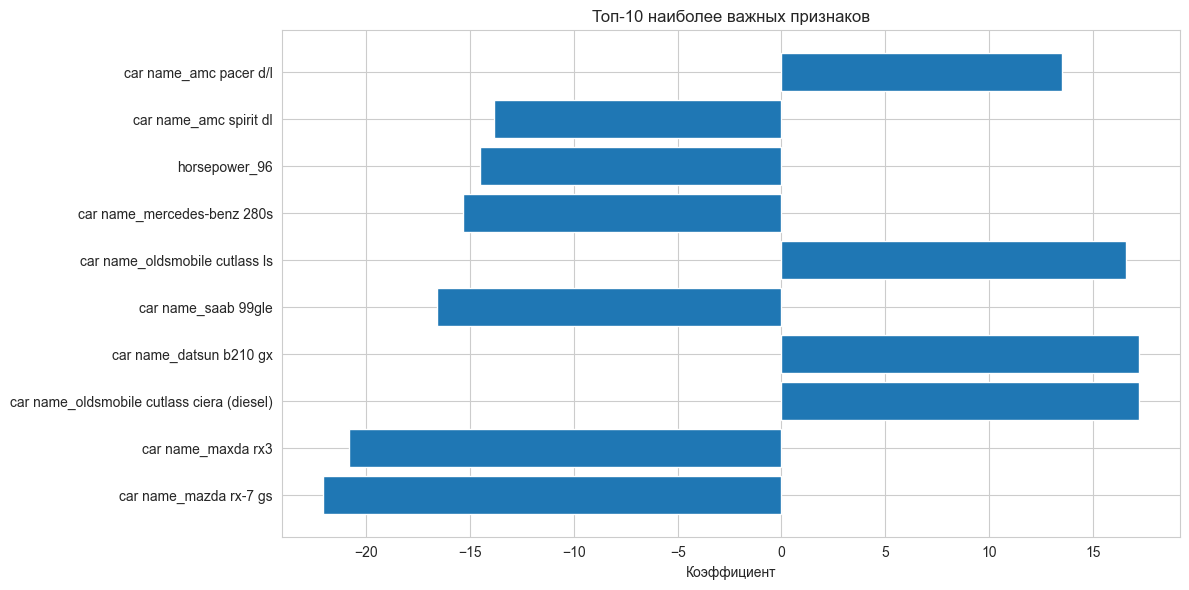


**Интерпретация:**
- Отрицательные коэффициенты уменьшают MPG (хуже расход топлива)
- Положительные коэффициенты увеличивают MPG (лучше расход топлива)
- Наиболее важные признаки имеют наибольшие абсолютные значения коэффициентов


In [24]:
feature_names = (numeric_features + 
                list(pipeline_lr.named_steps['preprocessor']
                     .named_transformers_['cat']
                     .get_feature_names_out(categorical_features)))

coefficients = pipeline_lr.named_steps['regressor'].coef_

feature_importance = pd.DataFrame({
    'Признак': feature_names,
    'Коэффициент': coefficients,
    'Абсолютное значение': np.abs(coefficients)
}).sort_values('Абсолютное значение', ascending=False)

print("\nВажность признаков (топ-10):")
print(feature_importance.head(10).to_string(index=False))

plt.figure(figsize=(12, 6))
top_features = feature_importance.head(10)
plt.barh(top_features['Признак'], top_features['Коэффициент'])
plt.xlabel('Коэффициент')
plt.title('Топ-10 наиболее важных признаков')
plt.tight_layout()
plt.show()